# C4 - Orbital Assembly Scheduling (CP-SAT)

**Cours:** EPITA 2026 - Programmation par Contraintes  
**Sujet README:** C4 - Assemblage orbital de satellites

Ce notebook constitue le livrable principal: formulation, implementation, baseline gloutonne, benchmark et analyse.

## 1) Formulation du probleme

On planifie un ensemble de manoeuvres orbitales pour assembler des modules en orbite.

Chaque manoeuvre `i` possede:
- une fenetre temporelle issue du croisement **lancement + communication sol**,
- un profil **fast** ou **eco** (compromis duree / delta-V),
- un couloir orbital `lane(i)`.

Parametrage orbital utilise dans le generateur:
- profils **LEO** et **GEO**,
- transfert principal derive d'un **Hohmann** simplifie,
- durees discretes en slots de 10 minutes,
- delta-V discret en unites de 10 m/s.

Contraintes principales:
1. **NoOverlap par couloir orbital**.
2. **Precedences** de sequence d'assemblage.
3. **Separation de securite** pour paires conflictuelles.
4. **Budget carburant total**.
5. **Capacite concurrente delta-V** via contrainte `Cumulative`.

Objectif: minimiser lexicographiquement (approximation ponderee) :
- le **makespan**, puis
- la consommation totale de carburant.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.instance_generator import generate_instance, maneuvers_dataframe
from src.solver_cp_sat import solve_cpsat
from src.baseline_greedy import solve_greedy
from src.validation import validate_schedule
from src.experiments import BenchmarkConfig, run_benchmark, summarize, export_results
from src.plotting import plot_schedule, plot_benchmark_summary, save_figure

PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

## 2) Instance d'etude (illustrative)

On commence par une instance representative pour visualiser la structure des donnees et des plannings.

In [3]:
instance = generate_instance(n_modules=8, horizon=420, seed=SEED)
print('Instance:', instance.name)
print('Horizon:', instance.horizon)
print('Maneuvers:', instance.n())
print('Precedences:', len(instance.precedences))
print('Safety conflicts:', len(instance.safety_conflicts))
print('Fuel budget:', instance.total_fuel_budget)
print('Concurrent DV capacity:', instance.concurrent_dv_capacity)

df_m = maneuvers_dataframe(instance)
display(df_m.head(12))

Instance: C4-synth-mod8-seed42
Horizon: 420
Maneuvers: 16
Precedences: 17
Safety conflicts: 3
Fuel budget: 424
Concurrent DV capacity: 254


,idx,module,phase,mission_regime,lane,orbit_from_km,orbit_to_km,base_delta_v_mps,base_time_s,window_open,window_close,comm_open,comm_close,duration_fast,duration_eco,dv_fast,dv_eco,name,earliest_start,latest_end
0,0,core,transfer,LEO,4,461,588,70,2854,3,150,8,149,4,5,8,7,core:transfer,8,149
1,1,core,docking,LEO,0,588,588,8,369,112,250,116,247,2,3,1,1,core:docking,116,247
2,2,propulsion,transfer,GEO,2,10053,35786,1755,24953,93,168,93,168,37,45,195,163,propulsion:transfer,93,168
3,3,propulsion,docking,GEO,3,35786,35786,182,3513,140,361,180,355,5,7,20,16,propulsion:docking,180,355
4,4,power_left,transfer,LEO,1,442,855,221,2931,45,162,47,158,4,5,25,22,power_left:transfer,47,158
5,5,power_left,docking,LEO,2,855,855,24,485,202,356,203,354,2,3,3,2,power_left:docking,203,354
6,6,power_right,transfer,LEO,1,617,616,1,2911,91,233,92,233,4,6,1,1,power_right:transfer,92,233
7,7,power_right,docking,LEO,2,616,616,8,420,257,367,257,367,2,3,1,1,power_right:docking,257,367
8,8,payload,transfer,LEO,1,663,730,36,2961,76,200,79,200,4,6,4,3,payload:transfer,79,200
9,9,payload,docking,LEO,2,730,730,8,244,213,380,219,380,2,3,1,1,payload:docking,219,380


In [4]:
cp_res = solve_cpsat(instance, time_limit_s=20.0, workers=8, seed=SEED)
gr_res = solve_greedy(instance)

print('CP-SAT  status:', cp_res.status)
print('CP-SAT  feasible:', cp_res.feasible)
print('CP-SAT  makespan:', cp_res.makespan)
print('CP-SAT  total fuel:', cp_res.total_fuel)
print('CP-SAT  objective:', cp_res.objective)
print('CP-SAT  solve time (s):', round(cp_res.wall_time_s, 4))
print()
print('Greedy  status:', gr_res.status)
print('Greedy  feasible:', gr_res.feasible)
print('Greedy  makespan:', gr_res.makespan)
print('Greedy  total fuel:', gr_res.total_fuel)
print('Greedy  objective:', gr_res.objective)

cp_check = validate_schedule(instance, cp_res.schedule)
gr_check = validate_schedule(instance, gr_res.schedule)
print('\nCP-SAT  validation:', cp_check['feasible'])
print('Greedy  validation:', gr_check['feasible'])

CP-SAT  status: OPTIMAL
CP-SAT  feasible: True
CP-SAT  makespan: 259
CP-SAT  total fuel: 371
CP-SAT  objective: 110446
CP-SAT  solve time (s): 0.0276

Greedy  status: FEASIBLE
Greedy  feasible: True
Greedy  makespan: 259
Greedy  total fuel: 424
Greedy  objective: 110499

CP-SAT  validation: True
Greedy  validation: True


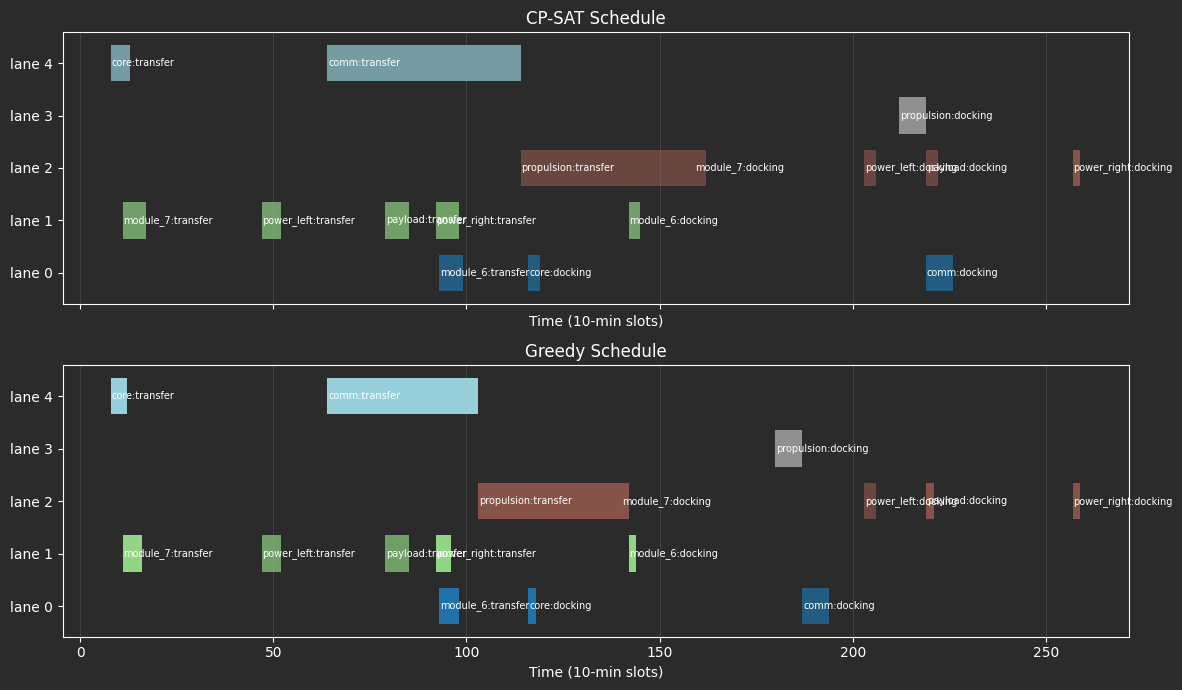

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plot_schedule(cp_res.schedule, title='CP-SAT Schedule', ax=axes[0])
plot_schedule(gr_res.schedule, title='Greedy Schedule', ax=axes[1])
plt.tight_layout()
save_figure(fig, FIG_DIR / 'single_instance_schedule_comparison.png')
plt.show()

## 3) Benchmark multi-instances

On evalue CP-SAT et la baseline gloutonne sur une famille d'instances de tailles croissantes.

- tailles modules: `4, 6, 8, 10, 12`
- seeds: `11, 22, 33, 44, 55`
- `time_limit=20s` par instance pour CP-SAT
- horizon adaptatif en fonction du nombre de modules

In [6]:
config = BenchmarkConfig(
    module_sizes=[4, 6, 8, 10, 12],
    seeds=[11, 22, 33, 44, 55],
    horizon=420,
    cp_time_limit_s=20.0,
    cp_workers=8,
)

raw = run_benchmark(config)
summary = summarize(raw)
export_results(raw, summary, RESULTS_DIR)

display(raw.head(10))
display(summary)

,instance_name,n_modules,n_maneuvers,seed,cp_status,cp_feasible,cp_valid,cp_objective,cp_makespan,cp_total_fuel,cp_time_s,gr_status,gr_feasible,gr_valid,gr_objective,gr_makespan,gr_total_fuel,gr_time_s
0,C4-synth-mod4-seed11,4,8,11,OPTIMAL,True,True,33076,196,148,0.012715,FEASIBLE,True,True,33599,199,167,0.229907
1,C4-synth-mod4-seed22,4,8,22,OPTIMAL,True,True,50366,226,194,0.010553,FEASIBLE,True,True,51059,229,221,0.262577
2,C4-synth-mod4-seed33,4,8,33,OPTIMAL,True,True,42691,180,211,0.016066,FEASIBLE,True,True,42950,181,234,0.294323
3,C4-synth-mod4-seed44,4,8,44,OPTIMAL,True,True,35595,198,153,0.008920,FEASIBLE,True,True,35620,198,178,0.270186
4,C4-synth-mod4-seed55,4,8,55,OPTIMAL,True,True,47932,221,196,0.013008,FEASIBLE,True,True,48383,223,215,0.369838
5,C4-synth-mod6-seed11,6,12,11,OPTIMAL,True,True,43709,221,172,0.014817,FEASIBLE,True,True,43930,222,196,0.291584
6,C4-synth-mod6-seed22,6,12,22,OPTIMAL,True,True,78446,234,290,0.023207,FEASIBLE,True,True,78480,234,324,0.309506
7,C4-synth-mod6-seed33,6,12,33,OPTIMAL,True,True,93871,257,323,0.013260,FEASIBLE,True,True,93911,257,363,0.258064
8,C4-synth-mod6-seed44,6,12,44,OPTIMAL,True,True,94793,246,329,0.025855,FEASIBLE,True,True,95231,247,383,0.294459
9,C4-synth-mod6-seed55,6,12,55,OPTIMAL,True,True,50368,227,201,0.015273,FEASIBLE,True,True,50829,229,220,0.262529


,n_modules,instances,cp_feasible_rate,cp_valid_rate,cp_mean_makespan,cp_mean_total_fuel,cp_mean_time_s,gr_feasible_rate,gr_valid_rate,gr_mean_makespan,gr_mean_total_fuel,gr_mean_time_s,paired_instances,cp_paired_mean_makespan,gr_paired_mean_makespan,cp_paired_mean_total_fuel,gr_paired_mean_total_fuel,mean_makespan_gain_pct,mean_fuel_gain_pct
0,4,5,1.0,1.0,204.2,180.4,0.012252,1.0,1.0,206.0,203.0,0.285366,5,204.2,206.0,180.4,203.0,0.853386,11.261131
1,6,5,1.0,1.0,237.0,263.0,0.018482,1.0,1.0,237.8,297.2,0.283228,5,237.0,237.8,263.0,297.2,0.345734,11.298718
2,8,5,1.0,1.0,240.2,313.4,0.018773,1.0,1.0,241.0,356.2,0.255042,5,240.2,241.0,313.4,356.2,0.348840,12.038995
3,10,5,1.0,1.0,243.0,357.4,0.021268,1.0,1.0,244.4,408.2,0.264005,5,243.0,244.4,357.4,408.2,0.596419,12.425123
4,12,5,1.0,1.0,254.4,420.4,0.024619,1.0,1.0,256.2,477.4,0.291892,5,254.4,256.2,420.4,477.4,0.670255,11.853362


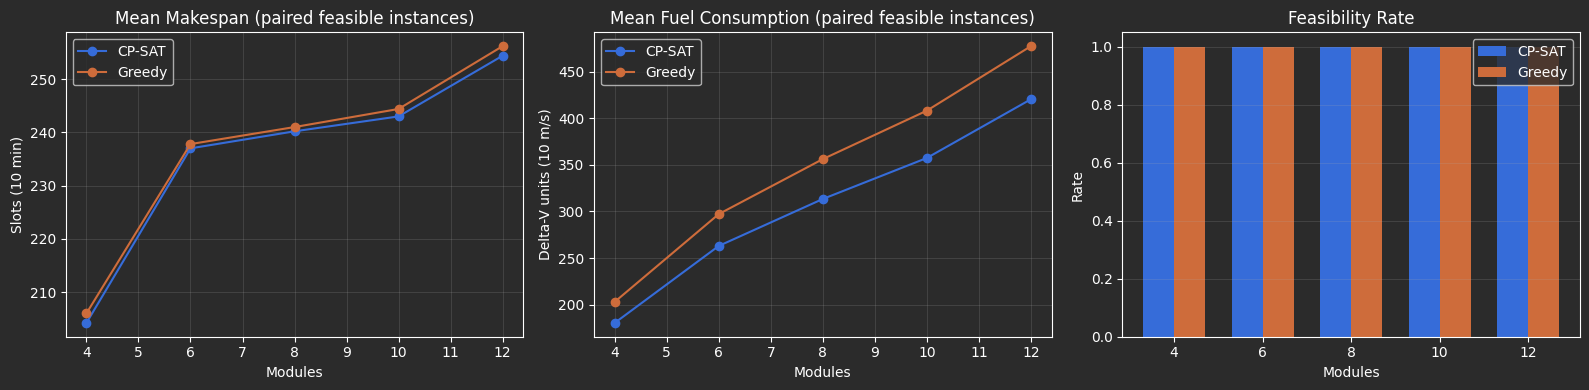

In [7]:
fig, axes = plot_benchmark_summary(summary)
save_figure(fig, FIG_DIR / 'benchmark_overview.png')
plt.show()

In [8]:
global_cp_feasible = raw['cp_feasible'].mean()
global_gr_feasible = raw['gr_feasible'].mean()

cp_feasible_rows = raw[raw['cp_feasible']]
gr_feasible_rows = raw[raw['gr_feasible']]

avg_cp_time = cp_feasible_rows['cp_time_s'].mean()
avg_cp_makespan = cp_feasible_rows['cp_makespan'].mean()
avg_gr_makespan = gr_feasible_rows['gr_makespan'].mean()
avg_cp_fuel = cp_feasible_rows['cp_total_fuel'].mean()
avg_gr_fuel = gr_feasible_rows['gr_total_fuel'].mean()

print('Global CP-SAT feasible rate :', round(100 * global_cp_feasible, 1), '%')
print('Global Greedy feasible rate :', round(100 * global_gr_feasible, 1), '%')
print('Mean CP-SAT solve time      :', round(avg_cp_time, 4), 's')
print('Mean makespan (CP-SAT)      :', round(avg_cp_makespan, 2))
print('Mean makespan (Greedy)      :', round(avg_gr_makespan, 2))
print('Mean fuel (CP-SAT)          :', round(avg_cp_fuel, 2))
print('Mean fuel (Greedy)          :', round(avg_gr_fuel, 2))

if avg_gr_makespan and not np.isnan(avg_gr_makespan):
    print('Makespan gain vs Greedy     :', round(100*(avg_gr_makespan-avg_cp_makespan)/avg_gr_makespan, 2), '%')
if avg_gr_fuel and not np.isnan(avg_gr_fuel):
    print('Fuel gain vs Greedy         :', round(100*(avg_gr_fuel-avg_cp_fuel)/avg_gr_fuel, 2), '%')

Global CP-SAT feasible rate : 100.0 %
Global Greedy feasible rate : 100.0 %
Mean CP-SAT solve time      : 0.0191 s
Mean makespan (CP-SAT)      : 235.76
Mean makespan (Greedy)      : 237.08
Mean fuel (CP-SAT)          : 306.92
Mean fuel (Greedy)          : 348.4
Makespan gain vs Greedy     : 0.56 %
Fuel gain vs Greedy         : 11.91 %


## 4) Discussion et conclusion

### Points forts
- Le modele CP-SAT capture proprement les contraintes structurelles de C4: fenetres, precedences, securite, `NoOverlap`, `Cumulative`.
- Le choix de mode `fast/eco` rend le budget carburant decisionnel (pas juste une constante).
- Les parametres orbitaux LEO/GEO et Hohmann rendent les instances plus plausibles que des tirages purement aleatoires.

### Limites
- Les orbites restent simplifiees (circularisation et discretisation temporelle).
- La communication est modelisee par enveloppes de visibilite, pas par union explicite de multiples passages.

### Extensions directes
- Integrer des fenetres derivees d'un propagateur orbital haute fidelite.
- Ajouter robustesse/stochastique (retards, perte de communication, marge carburant).
- Passer a une optimisation multi-objectif Pareto (makespan, fuel, risque, fenetres sol).


## 5) Artefacts exportes

Le notebook exporte automatiquement:
- `results/benchmark_raw.csv`
- `results/benchmark_summary.csv`
- `results/figures/benchmark_overview.png`
- `results/figures/single_instance_schedule_comparison.png`